Setup

In [1]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
jlPkg.activate("../../.")
jl.include("rl_repressilator_past_amort_setup.jl")
#jlPkg.instantiate() #run the first time using this repo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


observation (generic function with 2 methods)

Second peak value: 0.7038096038235359


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class Custom1DCNNExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128, obs_dim=128, action_dim=4, n_steps=5):
        super(Custom1DCNNExtractor, self).__init__(observation_space, features_dim)

        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.n_steps = n_steps

        n_input_channels = 1
        seq_len = obs_dim

        self.cnn = nn.Sequential(
            nn.Conv1d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        with th.no_grad():
            sample_obs = th.zeros((1, n_input_channels, seq_len), dtype=th.float32)
            cnn_output_dim = self.cnn(sample_obs).shape[1]

        combined_dim = self.n_steps * cnn_output_dim + self.n_steps * action_dim

        self.linear = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        """
        observations: (batch, 1, obs1 + act1 + ... + obs5 + act5)
        """
        obs_feats = []
        act_feats = []

        for i in range(self.n_steps):
            obs_start = i * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            act_end = act_start + self.action_dim

            obs = observations[:, :, obs_start:act_start]         # (batch, 1, obs_dim)
            act = observations[:, 0, act_start:act_end]           # (batch, action_dim)

            obs_feat = self.cnn(obs)                              # (batch, cnn_output_dim)
            obs_feats.append(obs_feat)
            act_feats.append(act)

        combined = th.cat(obs_feats + act_feats, dim=1)
        return self.linear(combined)


import random
import torch
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from gymnasium.utils import seeding
class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):  # now 5 steps
        super(CustomEnv, self).__init__()

        self.obs_dim = 128
        self.action_dim = 4
        self.n_steps = 5

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(2)

        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)
    
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")
        return [seed]
    

    def reset(self, seed=None, options=None):
        if options is not None and 'uncertain' in options:
            self.uncertain = options['uncertain']
        else:
            self.uncertain = np.random.rand(2) * 2 - 1

        if seed is not None:
            self.seed(seed)
        
        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        params_action = np.concatenate((self.uncertain, action))
        reward = jl.reward_normalized_past_amort(params_action, 1 / 7)
        rew = np.clip(reward, -5, 5)

        obs_vector = jl.observation(self.uncertain, action)
        obs_vector = np.array(obs_vector).reshape(1, -1).astype(np.float32)

        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim

            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), rew, terminated, truncated, info


In [3]:
from stable_baselines3.common.env_checker import check_env
env = CustomEnv()
check_env(env)

c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\stable_baselines3\common\env_checker.py:316: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


Training

In [ ]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# =============================== #
# ✅ Logging and Monitor
# =============================== #
log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5/"
os.makedirs(log_dir, exist_ok=True)


SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})") 
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

policy_kwargs = dict(
    features_extractor_class=Custom1DCNNExtractor,
    features_extractor_kwargs=dict(features_dim=128),
)

model = PPO(
    "CnnPolicy", 
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log=log_dir,
    seed=SEED
)



Using cpu device
Wrapping the env in a DummyVecEnv.


In [7]:
model.learn(total_timesteps=750000)

obs, info = env.reset()
action, _ = model.predict(obs)
print("Test action:", action)

Logging to logs/rl_repressilator_past_amort_multi_step_frame_5/PPO_1


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | -0.166   |
| time/              |          |
|    fps             | 11       |
|    iterations      | 1        |
|    time_elapsed    | 178      |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | -0.176      |
| time/                   |             |
|    fps                  | 10          |
|    iterations           | 2           |
|    time_elapsed         | 378         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013178771 |
|    clip_fraction        | 0.187       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.66       |
|    explained_variance   | -0.0012     |
|    learning_rate        | 0.

In [8]:
model.save(os.path.join(log_dir, "ppo_model"))

Evaluation

In [9]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
log_dir = "logs/rl_repressilator_past_amort_multi_step_frame_5"
model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

In [10]:
model = PPO.load(model_path)


C:\Users\micha\AppData\Local\Temp\ipykernel_57424\3935325265.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


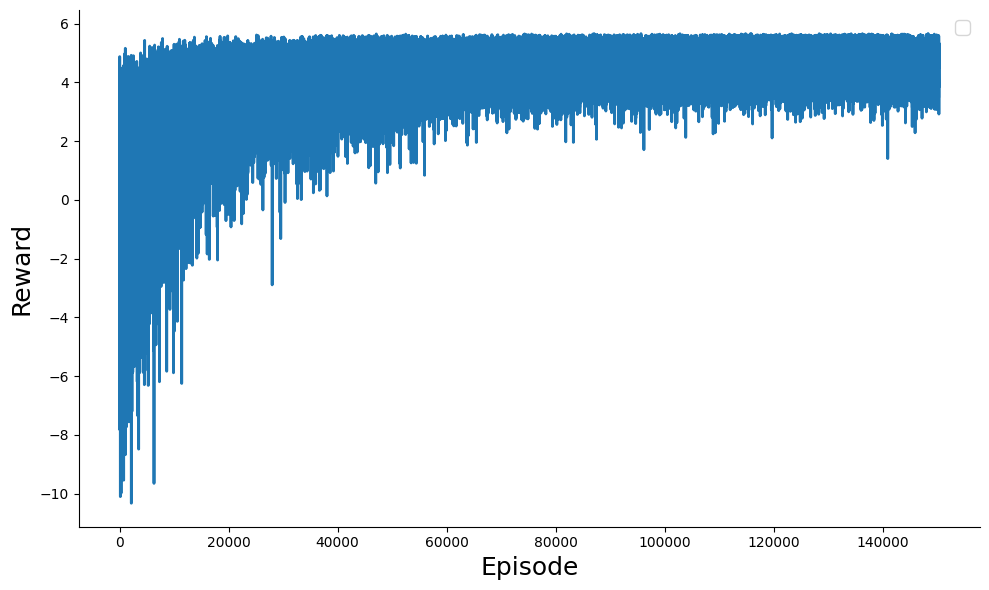

In [11]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(df)), y=df["r"], linewidth=2)

plt.xlabel("Episode", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()


Action taken: [-0.01579966 -1.          1.          0.38922545]
False
First reward: 0.9552249189931151
(1, 660)
Action taken: [ 0.3354673  -0.60728264  1.          1.        ]
Second reward: 0.8245132831314661


C:\Users\micha\AppData\Local\Temp\ipykernel_57424\4038937236.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Action taken: [ 1.         -0.4924116   1.          0.15858641]
Third reward: 0.8396583282301565
False


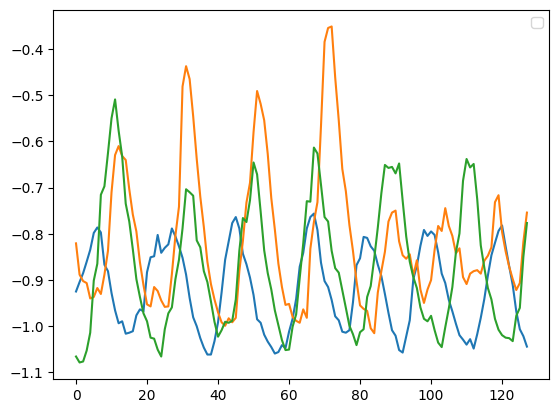

In [12]:
obs, info = env.reset()  # Reset the environment with a specific frequency

action, _states = model.predict(obs, deterministic=True)
action
print("Action taken:", action)
first_params = np.hstack((env.uncertain, action))



# print("First Reward:",jl.reward_normalized_past_amort(first_params, 1/7))
obs, reward, terminated, truncated, info = env.step(action)
print(terminated)

print("First reward:", reward)
print(obs.shape)

# plt.plot(jl.observation_normalized(np.concatenate((env.uncertain, action))), label="Second Design")
plt.legend()
# Take action in the environment

action, _states = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Second reward:", reward)

plt.plot(obs[0,0:128], label="First Design")
plt.plot(obs[0,132:260], label="Second Design")

action, _states = model.predict(obs, deterministic=True)

plt.plot(jl.observation(env.uncertain, action), label="Third Design")

obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Third reward:", reward)


print(terminated)




In [13]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5



Text(0, 0.5, 'Reward')

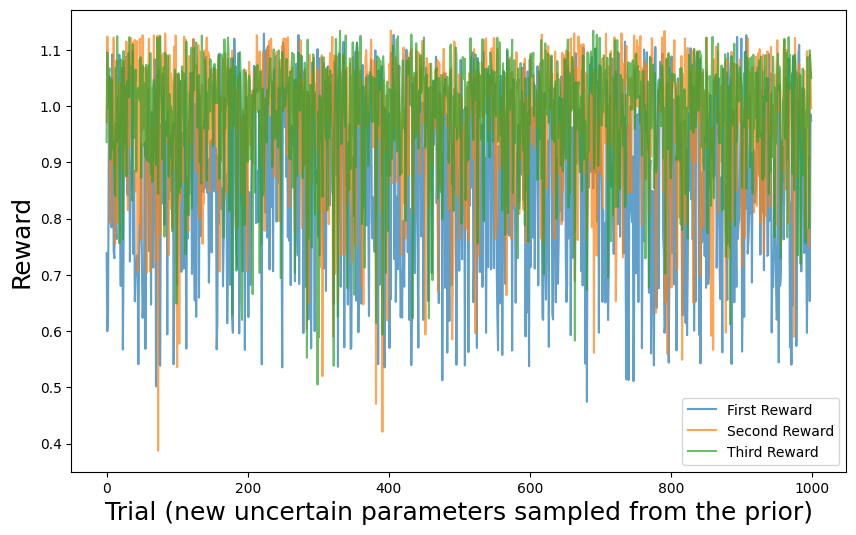

In [14]:

plt.figure(figsize=(10, 6))
plt.plot(first_rewards, label='First Reward', alpha=0.7)
plt.plot(second_rewards, label='Second Reward', alpha=0.7)
plt.plot(third_rewards, label='Third Reward', alpha=0.7)
plt.legend()
plt.xlabel("Trial (new uncertain parameters sampled from the prior)", fontsize=18)
plt.ylabel("Reward", fontsize=18)


Text(0, 0.5, 'Reward')

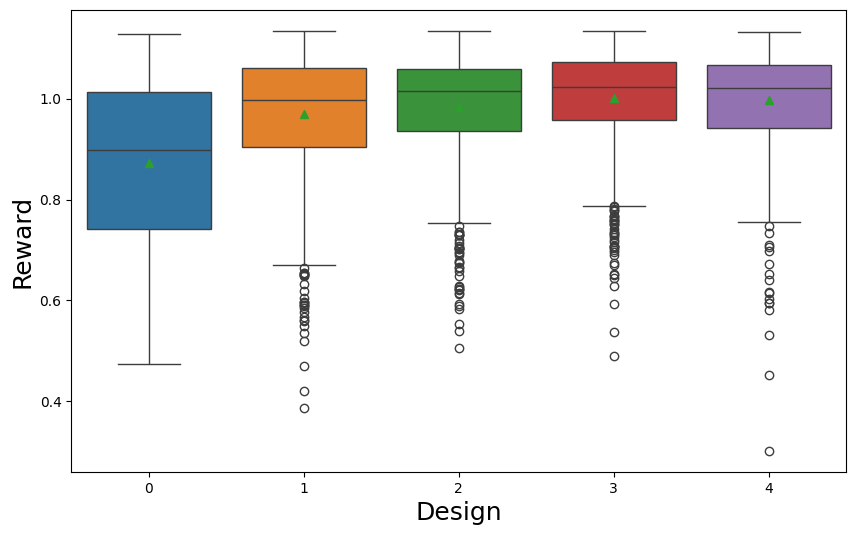

In [15]:
#plot boxplot seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[first_rewards, second_rewards, third_rewards,forth_rewards, fifth_rewards],showmeans=True)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)

In [16]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset()
    env.uncertain = np.zeros(2)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7) + jl.reward_normalized_past_amort(np.hstack((env.uncertain, action)), 1/7))/ 5



In [39]:
import numpy as np
import matplotlib.pyplot as plt
env.seed(31415)
def stacked_amort_heatmap(env, action, step_idx, num_samples=10):
    amort_outputs = []
    for _ in range(num_samples):
        out = jl.plot_amort(np.hstack([env.uncertain, action]))
        amort_outputs.append(out)
    return amort_outputs

obs, info = env.reset()
env.uncertain = np.ones(2)
env.seed(31415)
print("Environment reset.")

# Step 1
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h1 = stacked_amort_heatmap(env, action, step_idx=1)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 1 reward:", reward)
print("Terminated:", terminated)

# Step 2
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h2 = stacked_amort_heatmap(env, action, step_idx=2)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 2 reward:", reward)
print("Terminated:", terminated)

# Step 3
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h3 = stacked_amort_heatmap(env, action, step_idx=3)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 3 reward:", reward)
print("Terminated:", terminated)

# Step 4
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h4 = stacked_amort_heatmap(env, action, step_idx=4)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 4 reward:", reward)
print("Terminated:", terminated)

# Step 5
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h5 = stacked_amort_heatmap(env, action, step_idx=5)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 5 reward:", reward)
print("Terminated:", terminated)

Environment reset.
Action taken: [-0.01579966 -1.          1.          0.38922545]
Step 1 reward: 0.3960887787136673
Terminated: False
Action taken: [ 0.5725784  -0.28441703  1.          1.        ]
Step 2 reward: 1.1349336562827872
Terminated: False
Action taken: [ 0.58114016 -0.5508652   1.          0.5645906 ]
Step 3 reward: 0.9672036323559348
Terminated: False
Action taken: [ 0.86533505 -0.49995023  1.          0.503266  ]
Step 4 reward: 1.110004491389101
Terminated: False
Action taken: [ 0.5123832  -0.7855097   1.          0.12413557]
Step 5 reward: 1.1124184309603689
Terminated: True


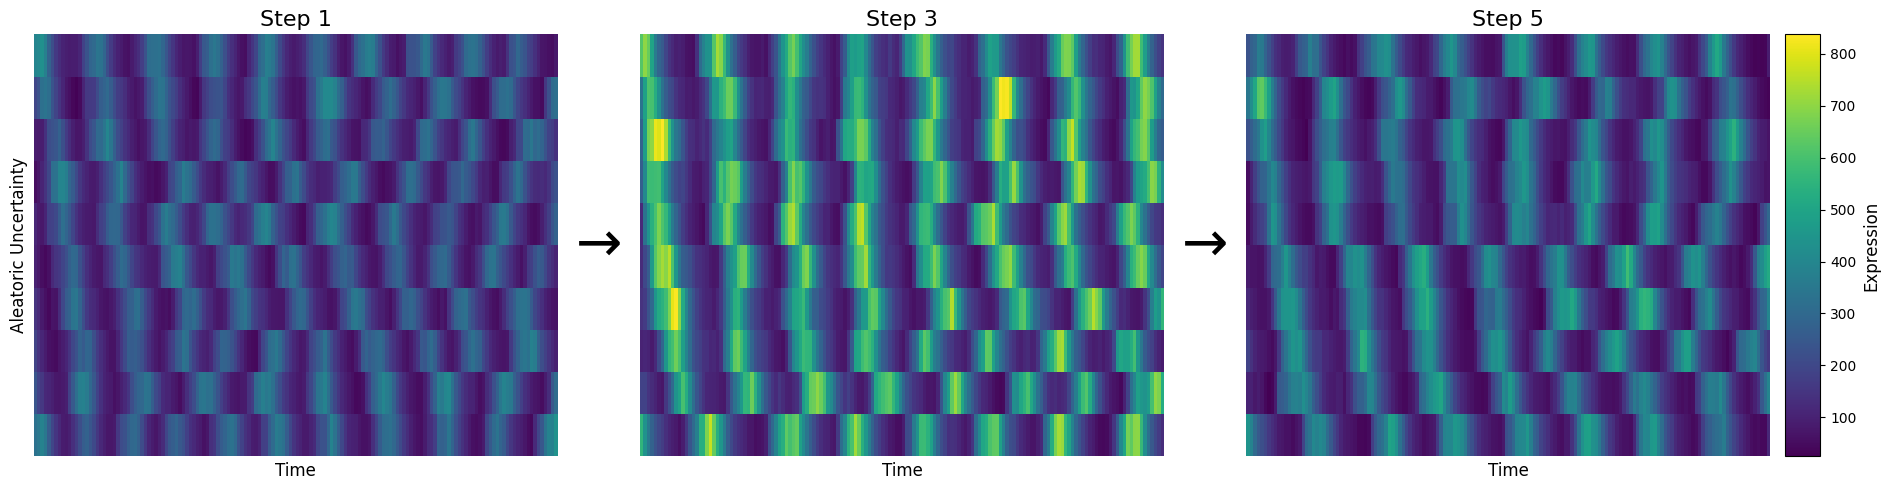

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.signal import find_peaks, savgol_filter

def sort_by_first_peak(matrix, smooth_window=30, poly_order=5, min_start_fraction=0.00, min_prominence=1):
    matrix = np.array(matrix) 
    n_timepoints = matrix.shape[1]
    min_start_index = int(n_timepoints * min_start_fraction)

    peak_positions = []
    for row in matrix:
        # Smooth the signal
        if len(row) >= smooth_window:
            smooth_row = savgol_filter(row, smooth_window, poly_order)
        else:
            smooth_row = row

        peaks, _ = find_peaks(smooth_row, prominence=min_prominence)

        peaks = peaks[peaks > min_start_index]

        if len(peaks) > 0:
            peak_positions.append(peaks[0])  # first valid peak
        else:
            peak_positions.append(np.inf)    # no valid peak found

    sorted_idx = np.argsort(peak_positions)
    return matrix[sorted_idx, :], sorted_idx

def plot_heatmaps_with_shared_colorbar(h_list, steps):
    num_plots = len(h_list)
    total_slots = num_plots * 2 - 1
    width_ratios = [6 if i % 2 == 0 else 0.6 for i in range(total_slots)]

    fig = plt.figure(figsize=(6 * num_plots + 1, 5))
    gs = GridSpec(1, total_slots + 1, width_ratios=width_ratios + [0.4])

    # Sort each heatmap independently
    h_list_sorted = [sort_by_first_peak(h)[0] for h in h_list]

    global_min = min(np.min(h) for h in h_list_sorted)
    global_max = max(np.max(h) for h in h_list_sorted)

    for i in range(num_plots):
        ax = fig.add_subplot(gs[0, i * 2])
        sns.heatmap(
            h_list_sorted[i],
            ax=ax,
            cbar=False,
            vmin=global_min,
            vmax=global_max,
            cmap='viridis'
        )

        ax.set_title(f"Step {steps[i]}", fontsize=16)
        if i == 0:
            ax.set_ylabel("Aleatoric Uncertainty", fontsize=12)
            ax.set_xlabel("Time", fontsize=12)
        else:
            ax.set_ylabel("")
            ax.set_xlabel("Time", fontsize=12)

        ax.set_xticks([])
        ax.set_yticks([])

    for i in range(num_plots - 1):
        ax_arrow = fig.add_subplot(gs[0, i * 2 + 1])
        ax_arrow.axis('off')
        ax_arrow.text(0.5, 0.5, '→', fontsize=40, ha='center', va='center', transform=ax_arrow.transAxes)

    cbar_ax = fig.add_subplot(gs[0, -1])
    norm = plt.cm.colors.Normalize(vmin=global_min, vmax=global_max)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Expression', fontsize=12)

    plt.tight_layout()
plot_heatmaps_with_shared_colorbar([h1, h3, h5], steps=[1, 3, 5])

plt.tight_layout()
plt.savefig("heatmaps_3_1.pdf", format="pdf")
plt.savefig("heatmaps_3_1.png", format="png")
plt.show()





In [41]:
import numpy as np
import matplotlib.pyplot as plt
env.seed(31415)
def stacked_amort_heatmap(env, action, step_idx, num_samples=10):
    amort_outputs = []
    for _ in range(num_samples):
        out = jl.plot_amort(np.hstack([env.uncertain, action]))
        amort_outputs.append(out)
    return amort_outputs

obs, info = env.reset()
env.uncertain = np.array([0,-0.9])
env.seed(31415)
print("Environment reset.")

# Step 1
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h1 = stacked_amort_heatmap(env, action, step_idx=1)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 1 reward:", reward)
print("Terminated:", terminated)

# Step 2
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h2 = stacked_amort_heatmap(env, action, step_idx=2)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 2 reward:", reward)
print("Terminated:", terminated)

# Step 3
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h3 = stacked_amort_heatmap(env, action, step_idx=3)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 3 reward:", reward)
print("Terminated:", terminated)

# Step 4
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h4 = stacked_amort_heatmap(env, action, step_idx=4)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 4 reward:", reward)
print("Terminated:", terminated)

# Step 5
action, _states = model.predict(obs, deterministic=True)
print("Action taken:", action)
h5 = stacked_amort_heatmap(env, action, step_idx=5)

obs, reward, terminated, truncated, info = env.step(action)
print("Step 5 reward:", reward)
print("Terminated:", terminated)

Environment reset.
Action taken: [-0.01579966 -1.          1.          0.38922545]
Step 1 reward: 0.8460316593953122
Terminated: False
Action taken: [ 0.6054537  -0.76708823  1.          1.        ]
Step 2 reward: 0.9836109050874533
Terminated: False
Action taken: [ 0.19909506 -0.8402346   1.          1.        ]
Step 3 reward: 0.9938376404939177
Terminated: False
Action taken: [ 1.        -0.7159152  1.         1.       ]
Step 4 reward: 1.1323071962158924
Terminated: False
Action taken: [ 0.46180493 -0.9391519   1.          0.723312  ]
Step 5 reward: 0.983942160261595
Terminated: True


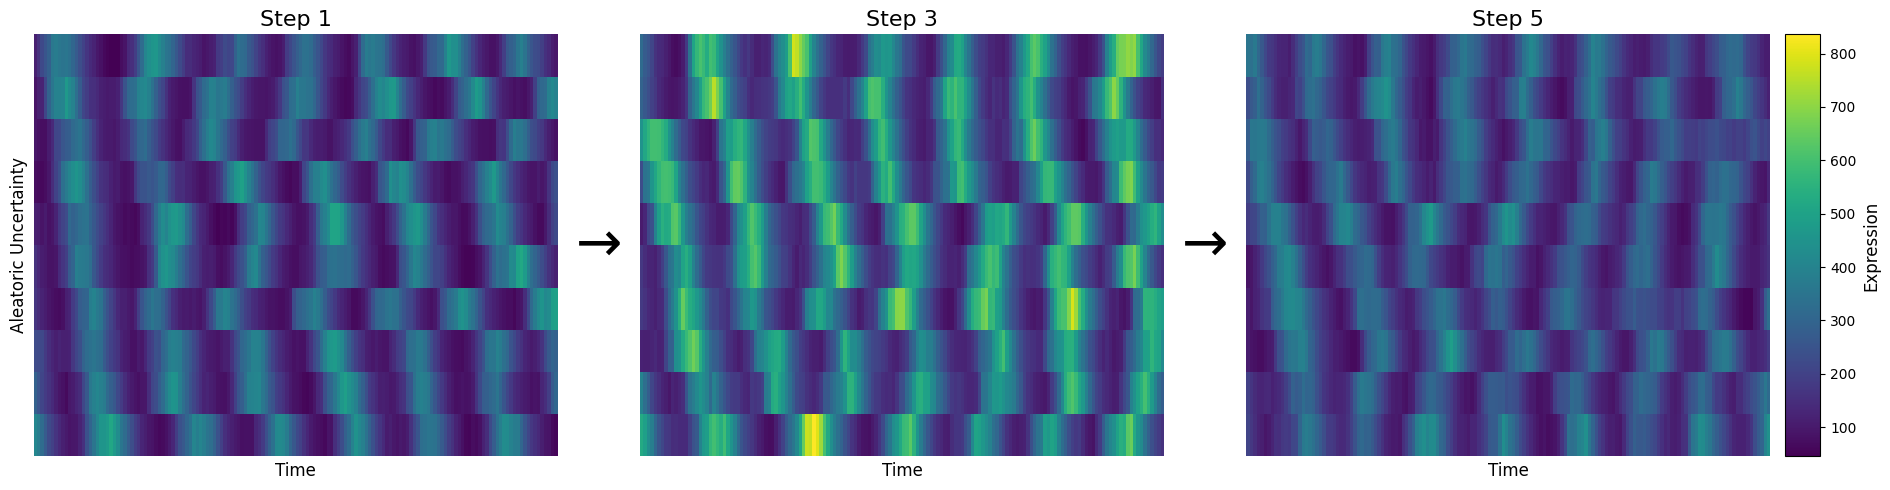

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.signal import find_peaks, savgol_filter

def sort_by_first_peak(matrix, smooth_window=30, poly_order=5, min_start_fraction=0.00, min_prominence=1):
    matrix = np.array(matrix) 
    n_timepoints = matrix.shape[1]
    min_start_index = int(n_timepoints * min_start_fraction)

    peak_positions = []
    for row in matrix:
        # Smooth the signal
        if len(row) >= smooth_window:
            smooth_row = savgol_filter(row, smooth_window, poly_order)
        else:
            smooth_row = row

        peaks, _ = find_peaks(smooth_row, prominence=min_prominence)

        peaks = peaks[peaks > min_start_index]

        if len(peaks) > 0:
            peak_positions.append(peaks[0])  # first valid peak
        else:
            peak_positions.append(np.inf)    # no valid peak found

    sorted_idx = np.argsort(peak_positions)
    return matrix[sorted_idx, :], sorted_idx

def plot_heatmaps_with_shared_colorbar(h_list, steps):
    num_plots = len(h_list)
    total_slots = num_plots * 2 - 1
    width_ratios = [6 if i % 2 == 0 else 0.6 for i in range(total_slots)]

    fig = plt.figure(figsize=(6 * num_plots + 1, 5))
    gs = GridSpec(1, total_slots + 1, width_ratios=width_ratios + [0.4])

    # Sort each heatmap independently
    h_list_sorted = [sort_by_first_peak(h)[0] for h in h_list]

    global_min = min(np.min(h) for h in h_list_sorted)
    global_max = max(np.max(h) for h in h_list_sorted)

    for i in range(num_plots):
        ax = fig.add_subplot(gs[0, i * 2])
        sns.heatmap(
            h_list_sorted[i],
            ax=ax,
            cbar=False,
            vmin=global_min,
            vmax=global_max,
            cmap='viridis'
        )

        ax.set_title(f"Step {steps[i]}", fontsize=16)
        if i == 0:
            ax.set_ylabel("Aleatoric Uncertainty", fontsize=12)
            ax.set_xlabel("Time", fontsize=12)
        else:
            ax.set_ylabel("")
            ax.set_xlabel("Time", fontsize=12)

        ax.set_xticks([])
        ax.set_yticks([])

    for i in range(num_plots - 1):
        ax_arrow = fig.add_subplot(gs[0, i * 2 + 1])
        ax_arrow.axis('off')
        ax_arrow.text(0.5, 0.5, '→', fontsize=40, ha='center', va='center', transform=ax_arrow.transAxes)

    cbar_ax = fig.add_subplot(gs[0, -1])
    norm = plt.cm.colors.Normalize(vmin=global_min, vmax=global_max)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Expression', fontsize=12)

    plt.tight_layout()
plot_heatmaps_with_shared_colorbar([h1, h3, h5], steps=[1, 3, 5])

plt.tight_layout()
plt.savefig("heatmaps_3_1.pdf", format="pdf")
plt.savefig("heatmaps_3_1.png", format="png")
plt.show()



